In [17]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


In [33]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA
languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            ]

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depths = layers.astype(float) / depths[modelB]

batch_shuffle = 0
centers_var = 'sem'
n_files = 21
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var = 'sem'
zero_activations_list = [0]
center_A_flags = [0,1,-1]


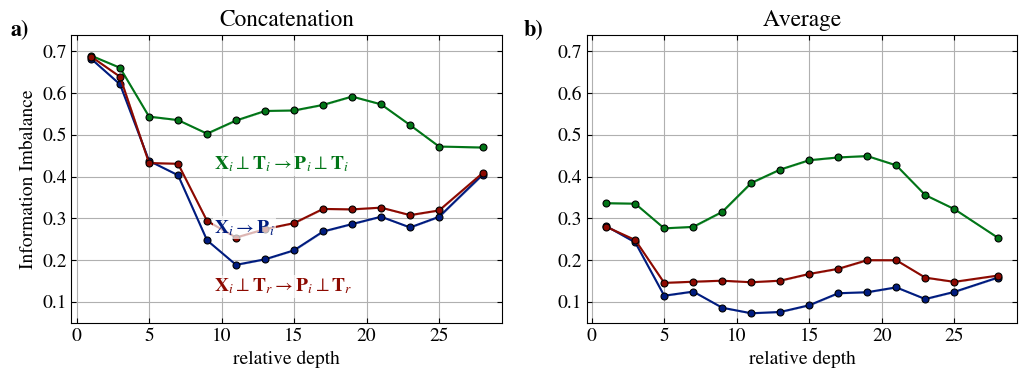

In [51]:
precision = 32

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
        removal_method = 'projection' if center_A_flag != 0 else None
        center_B_flag = center_A_flag
        number_of_languages = 6 if center_A_flag != 0 else None
        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=precision,
                                    language='english',
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=min_token_length,
                                    )
        II_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=zero_activations,
                                          center_A_flag=center_A_flag,
                                          center_B_flag=center_B_flag,
                                          number_of_languages=number_of_languages,
                                          language_list_permutation=0 if number_of_languages is not None else None,
                                          removal_method=removal_method,
                                          )
        inf_imb = np.load(II_folder + "II.npy")
        std = np.load(II_folder + "II_jack_std.npy")
        
        color = colors[plot_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average'
        else:
          title = f'Concatenation'

        label = ''
        if center_A_flag == 0:
          label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
        if center_A_flag == -1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
        if center_A_flag == 1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'

        for II_index in range(1):
          ax[avg_id].plot(
              layers,
              inf_imb[II_index].diagonal(),
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              marker='o',                # circular marker
              markersize=5,              # tweakable size
              markerfacecolor=color,     # fill same as line
              markeredgecolor='black',   # cute black border
              markeredgewidth=0.8,       # adjust border thickness
          )

          ax[avg_id].fill_between(layers,
                          inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                          inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                          alpha=0.2,
                          color=color,
                          )
        plot_id += 1

  ax[avg_id].set_xlabel('relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(0.05,.74)

  ax[avg_id].set_title(title)

enum_line = 0
for line in ax[0].lines:
    if enum_line == 0:
      _va = 'bottom' 
      _aux_y = 2
    elif enum_line == 1:
      _va = 'top'
      _aux_y = -15
    elif enum_line == 2:
      _va = 'top'
      _aux_y = -40
    label = line.get_label()
    if not label:
        continue
    xdata, ydata = line.get_xdata(), line.get_ydata()
    ax[0].annotate(
        label,
        xy=(xdata[len(xdata)//3], ydata[len(xdata)//3]),
        xytext=(5, _aux_y),  # offset in points
        textcoords='offset points',
        fontsize=14,
        color=line.get_color(),
        ha='left',
        va=_va,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    enum_line += 1

# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )


os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/semantic_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()



### Correlation coefficient 

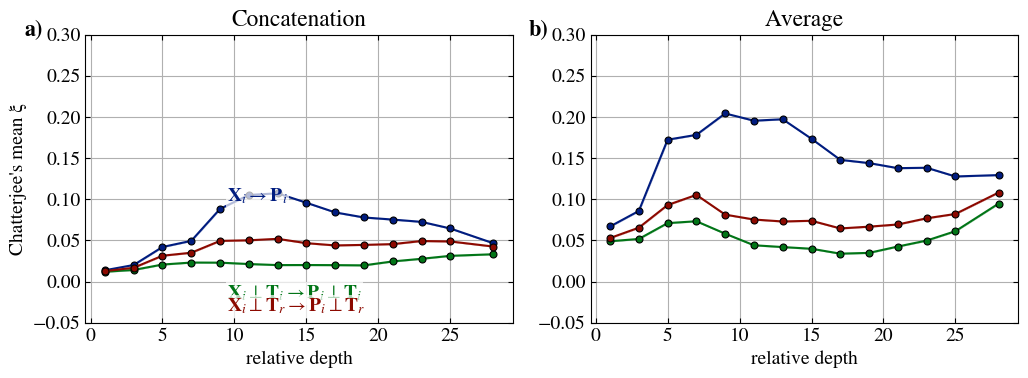

In [ ]:
### mean and std of xis: 
precision = 32

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
for avg_id,avg_tokens in enumerate(avg_flags):
  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
        removal_method = 'projection' if center_A_flag != 0 else None
        center_B_flag = center_A_flag
        number_of_languages = 6 if center_A_flag != 0 else None
        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=precision,
                                    language='english',
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=min_token_length,
                                    )
        II_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=zero_activations,
                                          center_A_flag=center_A_flag,
                                          center_B_flag=center_B_flag,
                                          number_of_languages=number_of_languages,
                                          language_list_permutation=0 if number_of_languages is not None else None,
                                          removal_method=removal_method,
                                          )
        
        corr_coeff_mu = np.load(II_folder + "corr_coeff.npy")
        corr_coeff_std = np.load(II_folder + "corr_coeff_jack_std.npy")
        
        color = colors[plot_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average'
        else:
          title = f'Concatenation'

        label = ''
        if center_A_flag == 0:
          label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
        if center_A_flag == -1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
        if center_A_flag == 1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'

        for II_index in range(1):
          ax[avg_id].plot(
              layers,
              corr_coeff_mu[II_index].diagonal(),
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              marker='o',                # circular marker
              markersize=5,              # tweakable size
              markerfacecolor=color,     # fill same as line
              markeredgecolor='black',   # cute black border
              markeredgewidth=0.8,       # adjust border thickness
          )

          ax[avg_id].fill_between(layers,
                          corr_coeff_mu[II_index].diagonal() - corr_coeff_std[II_index].diagonal(),
                          corr_coeff_mu[II_index].diagonal() + corr_coeff_std[II_index].diagonal(),
                          alpha=0.2,
                          color=color,
                          )
        plot_id += 1

  ax[avg_id].set_xlabel('relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel("Chatterjee's mean ξ")

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  ax[avg_id].set_ylim(-0.05,.3)

  ax[avg_id].set_title(title)

enum_line = 0
for line in ax[0].lines:
    if enum_line == 0:
      _va = 'bottom' 
      _aux_y = 2
    elif enum_line == 1:
      _va = 'top'
      _aux_y = -15
    elif enum_line == 2:
      _va = 'top'
      _aux_y = -40
    label = line.get_label()
    if not label:
        continue
    xdata, ydata = line.get_xdata(), line.get_ydata()
    ax[0].annotate(
        label,
        xy=(xdata[len(xdata)//3], ydata[len(xdata)//3]),
        xytext=(5, _aux_y),  # offset in points
        textcoords='offset points',
        fontsize=14,
        color=line.get_color(),
        ha='left',
        va=_va,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    enum_line += 1

# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/semantic_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()

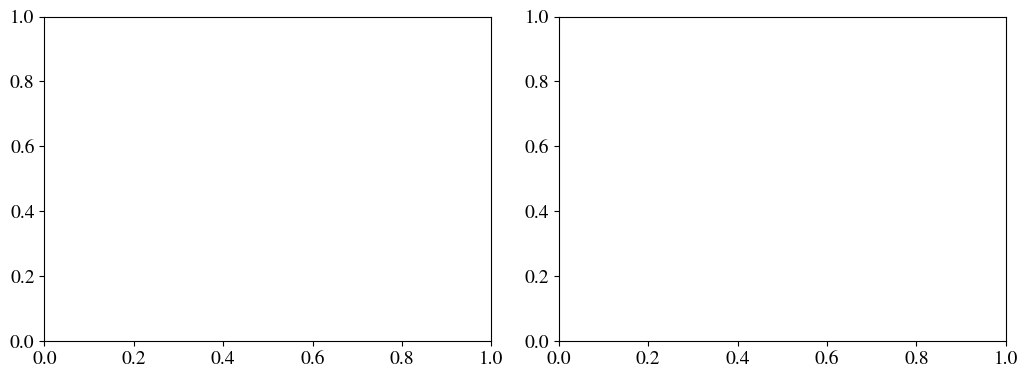

In [ ]:
precision = 32

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
for avg_id,avg_tokens in enumerate(avg_flags[:1]):
  title = ' '
  plot_id = 0
  if avg_tokens:
    min_token_length = -1
  else:
    min_token_length = 3
  n_tokens = min_token_length
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
        if center_A_flag != 0: continue 
        removal_method = 'projection' if center_A_flag != 0 else None
        center_B_flag = center_A_flag
        number_of_languages = 6 if center_A_flag != 0 else None
        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=precision,
                                    language='english',
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=min_token_length,
                                    )
        corr_coeff_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=zero_activations,
                                          center_A_flag=center_A_flag,
                                          center_B_flag=center_B_flag,
                                          number_of_languages=number_of_languages,
                                          language_list_permutation=0 if number_of_languages is not None else None,
                                          removal_method=removal_method,
                                          )
        for layer_A in layers:
          all_xis = np.load(corr_coeff_folder + f'all_corr_AB_layer{layer_A}.npy')
        corr_coeff_mu = np.load(II_folder + "corr_coeff.npy")
        corr_coeff_std = np.load(II_folder + "corr_coeff_jack_std.npy")
        plt.
        color = colors[plot_id] 
        linestyle = '-'
        if avg_tokens:
          title = f'Average'
        else:
          title = f'Concatenation'

        label = ''
        if center_A_flag == 0:
          label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
        if center_A_flag == -1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
        if center_A_flag == 1:
          label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'

  #       for II_index in range(1):
  #         ax[avg_id].plot(
  #             layers,
  #             inf_imb[II_index].diagonal(),
  #             label=label,
  #             linestyle=_linestyles[II_index],
  #             color=color,
  #             marker='o',                # circular marker
  #             markersize=5,              # tweakable size
  #             markerfacecolor=color,     # fill same as line
  #             markeredgecolor='black',   # cute black border
  #             markeredgewidth=0.8,       # adjust border thickness
  #         )

  #         ax[avg_id].fill_between(layers,
  #                         inf_imb[II_index].diagonal() - std[II_index].diagonal(),
  #                         inf_imb[II_index].diagonal() + std[II_index].diagonal(),
  #                         alpha=0.2,
  #                         color=color,
  #                         )
  #       plot_id += 1

  # ax[avg_id].set_xlabel('relative depth')
  # if avg_id == 0:
  #   ax[avg_id].set_ylabel('Information Imbalance')

  # ax[avg_id].grid()
  # ax[avg_id].tick_params(
  #     top=True, bottom=True, left=True, right=True,  # enable ticks
  #     labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
  #     direction='in'  # ticks point inward
  #     )
  # ax[avg_id].set_ylim(-0.05,.3)

  # ax[avg_id].set_title(title)




os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/semantic_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()



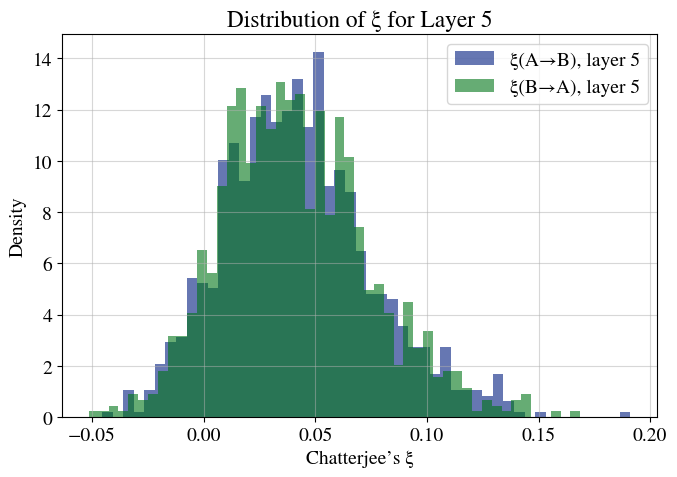

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import os

layer = 5  # choose your layer index here

# Load AB and BA correlations
corr_AB = np.load(os.path.join(corr_folder, f"all_corr_AB_layer{layer}.npy"))
corr_BA = np.load(os.path.join(corr_folder, f"all_corr_BA_layer{layer}.npy"))

# Flatten in case they’re not 1D
corr_AB = corr_AB.ravel()
corr_BA = corr_BA.ravel()

# Plot
plt.figure(figsize=(7, 5))
plt.hist(corr_AB, bins=50, density=True, alpha=0.6, label=f"ξ(A→B), layer {layer}")
plt.hist(corr_BA, bins=50, density=True, alpha=0.6, label=f"ξ(B→A), layer {layer}")

plt.xlabel("Chatterjee’s ξ")
plt.ylabel("Density")
plt.title(f"Distribution of ξ for Layer {layer}")
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Found layers: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 28]


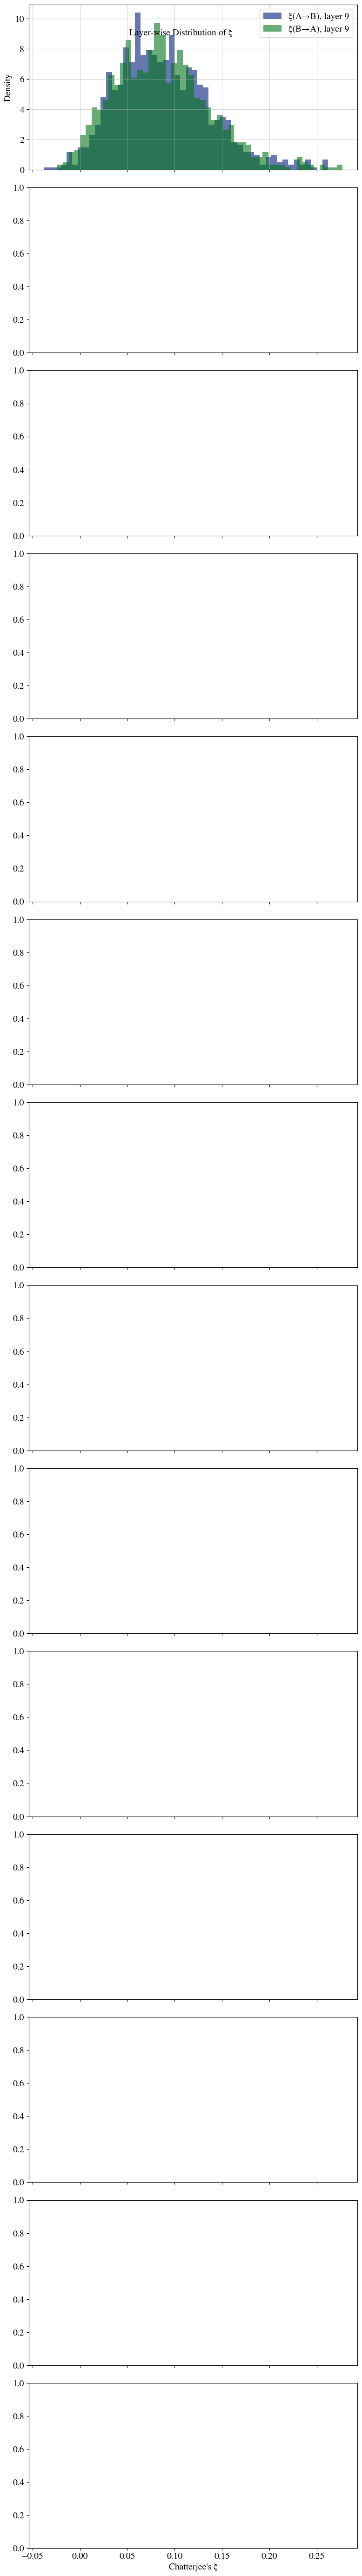

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Path to your correlation results
corr_folder = corr_coeff_folder

# Detect layers automatically
layer_ids = sorted(
    {int(os.path.basename(f).split("layer")[1].split(".npy")[0])
     for f in glob.glob(os.path.join(corr_folder, "all_corr_AB_layer*.npy"))}
)

print(f"Found layers: {layer_ids}")

# Create subplots — one per layer
n_layers = len(layer_ids)
fig, axes = plt.subplots(n_layers, 1, figsize=(8, 4 * n_layers), sharex=True)

if n_layers == 1:
    axes = [axes]  # make iterable

layer_ids = [layer_ids[4]]
for ax, layer in zip(axes, layer_ids):
    # Load AB and BA correlations
    corr_AB = np.load(os.path.join(corr_folder, f"all_corr_AB_layer{layer}.npy"))
    corr_BA = np.load(os.path.join(corr_folder, f"all_corr_BA_layer{layer}.npy"))
    
    # Flatten (just in case)
    corr_AB = corr_AB.ravel()
    corr_BA = corr_BA.ravel()

    # Plot histograms
    ax.hist(corr_AB, bins=50, density=True, alpha=0.6, label=f"ξ(A→B), layer {layer}")
    ax.hist(corr_BA, bins=50, density=True, alpha=0.6, label=f"ξ(B→A), layer {layer}")

    # Labels, grid, etc.
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.5)

# Shared X label
axes[-1].set_xlabel("Chatterjee's ξ")
fig.suptitle("Layer-wise Distribution of ξ", fontsize=14)
plt.tight_layout()
plt.show()


In [37]:
# precision = 32
# fig,ax = plt.subplots(1,2,figsize=(10.5,4))

# for avg_id, avg_tokens in enumerate([0, 1]):
#     for sim_id,similarity_fn in enumerate(['normalized_L2_distance','L2_distance']):

#         title0 = ' Semantic similarity:  '
#         plot_id = 0
#         if avg_tokens:
#             min_token_length = -1
#         else:
#             min_token_length = 3
#         n_tokens = min_token_length
#         for zero_id,zero_activations in enumerate(zero_activations_list):
#             for center_A_id,center_A_flag in enumerate(center_A_flags):
#                 removal_method = 'projection' if center_A_flag != 0 else None
#                 center_B_flag = center_A_flag
#                 number_of_languages = 6 if center_A_flag != 0 else None
#                 output_folder0 = makefolder(base=f'./results/',
#                                             global_centering=0,
#                                             spaces='AB',
#                                             similarity_fn=similarity_fn,
#                                             precision=precision,
#                                             language='english',
#                                             data_var=data_var,
#                                             modelA=modelA,
#                                             modelB=modelB,
#                                             match_var=match_var,
#                                             n_files=n_files,
#                                             min_token_length=min_token_length,
#                                             )
#                 II_folder = makefolder(base=output_folder0,
#                                                 centers=centers_var,
#                                                 Nbits=Nbits,
#                                                 n_tokens=n_tokens,
#                                                 avg_tokens=avg_tokens,
#                                                 batch_shuffle=batch_shuffle,
#                                                 zero_activations=zero_activations,
#                                                 center_A_flag=center_A_flag,
#                                                 center_B_flag=center_B_flag,
#                                                 number_of_languages=number_of_languages,
#                                                 language_list_permutation=0 if number_of_languages is not None else None,
#                                                 removal_method=removal_method,
#                                                 )
#                 inf_imb = np.load(II_folder + "II.npy")
#                 std = np.load(II_folder + "II_jack_std.npy")
                
#                 color = colors[plot_id] 
#                 linestyle = '-'
#                 if avg_tokens:
#                     title = title0 + f'Average'
#                 else:
#                     title = title0 + f'Concatenation'

#                 label = ''
#                 # label += f'{similarity_fn}'
#                 if center_A_flag == 0:
#                     label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
#                 if center_A_flag == -1:
#                     label += r'$\mathbf{X}_i \perp \mathbf{T}_r \rightarrow \mathbf{P}_i \perp \mathbf{T}_r$'
#                 if center_A_flag == 1:
#                     label += r'$\mathbf{X}_i \perp \mathbf{T}_i \rightarrow \mathbf{P}_i \perp \mathbf{T}_i $'

#                 for II_index in range(1):
#                     ax[avg_id].plot(
#                         layers,
#                         inf_imb[II_index].diagonal(),
#                         label=label,
#                         linestyle=_linestyles[sim_id],
#                         color=color,
#                         marker='o',                # circular marker
#                         markersize=5,              # tweakable size
#                         markerfacecolor=color,     # fill same as line
#                         markeredgecolor='black',   # cute black border
#                         markeredgewidth=0.8,       # adjust border thickness
#                     )

#                     ax[avg_id].fill_between(layers,
#                                     inf_imb[II_index].diagonal() - std[II_index].diagonal(),
#                                     inf_imb[II_index].diagonal() + std[II_index].diagonal(),
#                                     alpha=0.2,
#                                     color=color,
#                                     )
#                     plot_id += 1

#     ax[avg_id].set_xlabel('relative depth')
#     if avg_id == 0:
#         ax[avg_id].set_ylabel('Information Imbalance')

#     ax[avg_id].grid()
#     ax[avg_id].tick_params(
#         top=True, bottom=True, left=True, right=True,  # enable ticks
#         labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
#         direction='in'  # ticks point inward
#         )
#     ax[avg_id].set_ylim(0.05,.85)

#     ax[avg_id].set_title(title)

#     # ax[0].legend()
# box = ax[1].get_position()
# ax[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))



# os.makedirs('results/figs', exist_ok=True)
# # fig.savefig(f'results/figs/semantic_similarity_{modelA}_{removal_method}.pdf', bbox_inches='tight')
# plt.show()

